In [1]:
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from pathlib import Path
from prudence_funct import hourly_rolling_cap, apply_soft_cap, plot_prudence_component, stationary_bootstrap_indices, revenue_scenarios_stationary_bootstrap

data_folder = Path.cwd()/"CSV"

In [2]:
# Data Import: FCR
fcr = pd.read_csv(data_folder/"FCR_NL2024.csv")
col = "NETHERLANDS_SETTLEMENTCAPACITY_PRICE_[EUR/MW]"

# Set missing values to NaN
fcr[col] = pd.to_numeric(
    fcr[col].replace("-", np.nan),
    errors="coerce"
)

n_missing = fcr[col].isna().sum()
print("Number of missing prices:", n_missing)

# data cleaning
fcr["DATE_FROM"] = pd.to_datetime(fcr["DATE_FROM"])
hours = fcr["PRODUCTNAME"].str.extract(r"(\d{2})_(\d{2})").astype(int)
fcr["start_hour"] = hours[0]
fcr["end_hour"] = hours[1]
fcr["hour"] = fcr.apply(
    lambda row: list(range(row["start_hour"], row["end_hour"])),
    axis=1
)
fcr = fcr.explode("hour")
fcr["datetime"] = fcr["DATE_FROM"] + pd.to_timedelta(fcr["hour"], unit="h")

fcr = fcr.drop(columns=["PRODUCTNAME", "start_hour", "end_hour", "hour"])

fcr["datetime"] = pd.to_datetime(fcr["datetime"], utc=True)
fcr = fcr.sort_values("datetime").set_index("datetime")
fcr = (
    fcr[["NETHERLANDS_SETTLEMENTCAPACITY_PRICE_[EUR/MW]"]]
    .rename(columns={"NETHERLANDS_SETTLEMENTCAPACITY_PRICE_[EUR/MW]": "FCR_capacity_EUR/MW"})
)
print(fcr.head())

Number of missing prices: 156
                           FCR_capacity_EUR/MW
datetime                                      
2024-01-01 00:00:00+00:00                  NaN
2024-01-01 01:00:00+00:00                  NaN
2024-01-01 02:00:00+00:00                  NaN
2024-01-01 03:00:00+00:00                  NaN
2024-01-01 04:00:00+00:00                  NaN


In [3]:
# Data Import: aFRR Capacity
afrr_cap = pd.read_csv(data_folder / "capacity_aFRR_NL.csv")

afrr_cap["datetime"] = pd.to_datetime(afrr_cap["datetime"], utc=True)

afrr_cap = (
    afrr_cap
    .set_index("datetime")
    .resample("1h")["Up"].mean()
    .to_frame(name="aFRR_capacity_UP_EUR/MW")
)

print(afrr_cap.head())

                           aFRR_capacity_UP_EUR/MW
datetime                                          
2023-12-31 23:00:00+00:00                    11.16
2024-01-01 00:00:00+00:00                    11.16
2024-01-01 01:00:00+00:00                    11.16
2024-01-01 02:00:00+00:00                    11.16
2024-01-01 03:00:00+00:00                    11.16


In [4]:
# Data Import: aFRR Activation
afrr_act = pd.read_csv(data_folder / "activated_aFRR_NL.csv")

afrr_act = afrr_act[afrr_act["Direction"] == "Up"].copy()

afrr_act["datetime"] = pd.to_datetime(afrr_act["datetime"], utc=True)

afrr_act = (
    afrr_act
    .set_index("datetime")
    .resample("1h")["Price"].mean()
    .to_frame(name="aFRR_activation_UP_EUR/MW")
)

print(afrr_act.head())

                           aFRR_activation_UP_EUR/MW
datetime                                            
2023-12-31 23:00:00+00:00                    73.4875
2024-01-01 00:00:00+00:00                    78.6275
2024-01-01 01:00:00+00:00                    63.8150
2024-01-01 02:00:00+00:00                    57.0525
2024-01-01 03:00:00+00:00                    65.6525


In [5]:
# Combine all three on their datetime index
best_case_revenue = pd.concat(
    [fcr, afrr_cap, afrr_act],
    axis=1
)

# Make sure columns are in the order you want
best_case_revenue = best_case_revenue[
    ["FCR_capacity_EUR/MW",
     "aFRR_capacity_UP_EUR/MW",
     "aFRR_activation_UP_EUR/MW"]
]

# Add sum of FCR + aFRR capacity
best_case_revenue["total_capacity_revenue_EUR/MW"] = (
    best_case_revenue["FCR_capacity_EUR/MW"]
    + best_case_revenue["aFRR_capacity_UP_EUR/MW"]
)

# Add sum of all three (FCR + aFRR cap + aFRR activation)
best_case_revenue["total_revenue_EUR/MW"] = (
    best_case_revenue["FCR_capacity_EUR/MW"]
    + best_case_revenue["aFRR_capacity_UP_EUR/MW"]
    + best_case_revenue["aFRR_activation_UP_EUR/MW"]
)

print(best_case_revenue.head(15))


                           FCR_capacity_EUR/MW  aFRR_capacity_UP_EUR/MW  \
datetime                                                                  
2023-12-31 23:00:00+00:00                  NaN                    11.16   
2024-01-01 00:00:00+00:00                  NaN                    11.16   
2024-01-01 01:00:00+00:00                  NaN                    11.16   
2024-01-01 02:00:00+00:00                  NaN                    11.16   
2024-01-01 03:00:00+00:00                  NaN                    11.16   
2024-01-01 04:00:00+00:00                  NaN                    11.16   
2024-01-01 05:00:00+00:00                  NaN                    11.16   
2024-01-01 06:00:00+00:00                  NaN                    11.16   
2024-01-01 07:00:00+00:00                  NaN                    11.16   
2024-01-01 08:00:00+00:00                  NaN                    11.16   
2024-01-01 09:00:00+00:00                  NaN                    11.16   
2024-01-01 10:00:00+00:00

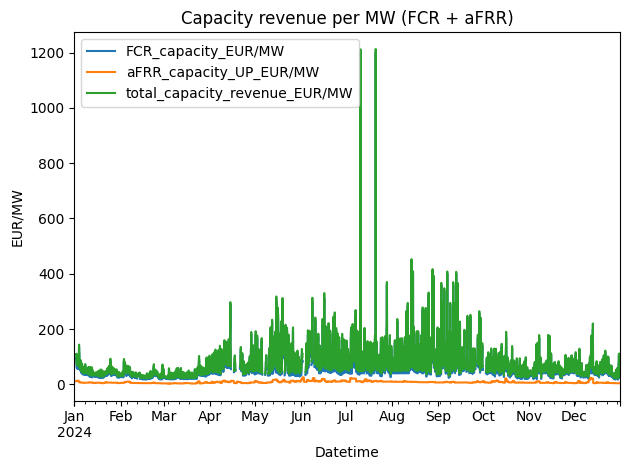

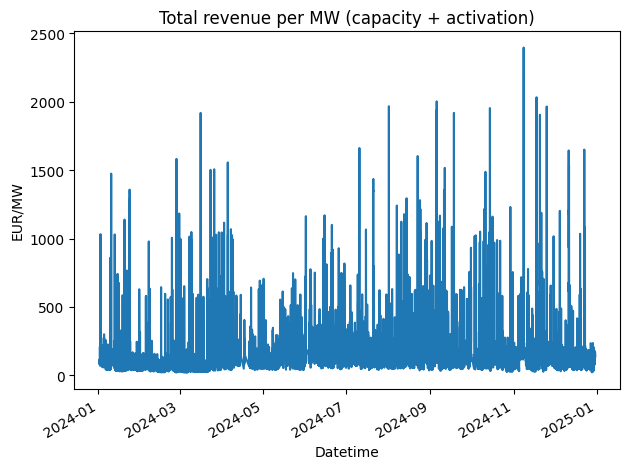

In [6]:
cap = best_case_revenue[
    ["FCR_capacity_EUR/MW", "aFRR_capacity_UP_EUR/MW", "total_capacity_revenue_EUR/MW"]
].dropna(how="all")

# 1) Capacity revenue only (FCR, aFRR_cap, and their sum)
fig, ax = plt.subplots()
cap.plot(ax=ax)
ax.set_title("Capacity revenue per MW (FCR + aFRR)")
ax.set_ylabel("EUR/MW")
ax.set_xlabel("Datetime")
plt.tight_layout()
plt.show()

# 2) Total revenue (capacity + activation)
tot = best_case_revenue["total_revenue_EUR/MW"].dropna()

fig, ax = plt.subplots()
tot.plot(ax=ax)
ax.set_title("Total revenue per MW (capacity + activation)")
ax.set_ylabel("EUR/MW")
ax.set_xlabel("Datetime")
plt.tight_layout()
plt.show()

In [7]:
min_max = best_case_revenue.agg(['min', 'max'])
print(min_max)

     FCR_capacity_EUR/MW  aFRR_capacity_UP_EUR/MW  aFRR_activation_UP_EUR/MW  \
min                17.21                     2.24                     0.0000   
max              1200.00                    25.47                  2339.0075   

     total_capacity_revenue_EUR/MW  total_revenue_EUR/MW  
min                          20.49               20.4900  
max                        1212.61             2396.6275  


In [8]:
# Prudence: rolling caps
df = best_case_revenue.copy()
df["hour"] = df.index.hour

# Choose prudence settings
WINDOW = "60D"
MINP_BY_HOUR = 14

# Component-specific caps - Increase q for less strict capping
cap_fcr = hourly_rolling_cap(df, "FCR_capacity_EUR/MW", WINDOW, q=0.97, min_periods=MINP_BY_HOUR)
cap_afrr_cap = hourly_rolling_cap(df, "aFRR_capacity_UP_EUR/MW", WINDOW, q=0.98, min_periods=MINP_BY_HOUR)
cap_afrr_act = hourly_rolling_cap(df, "aFRR_activation_UP_EUR/MW", WINDOW, q=0.95, min_periods=MINP_BY_HOUR)

# Apply caps - Increase alpha for more strict capping
best_case_revenue["FCR_capacity_prudent"] = apply_soft_cap(df["FCR_capacity_EUR/MW"], cap_fcr, alpha=0.10)
best_case_revenue["aFRR_capacity_UP_prudent"] = apply_soft_cap(df["aFRR_capacity_UP_EUR/MW"], cap_afrr_cap, alpha=0.10)
best_case_revenue["aFRR_activation_UP_prudent"] = apply_soft_cap(df["aFRR_activation_UP_EUR/MW"], cap_afrr_act, alpha=0.10)

# Recompute prudent totals
best_case_revenue["total_capacity_revenue_prudent"] = (
    best_case_revenue["FCR_capacity_prudent"] +
    best_case_revenue["aFRR_capacity_UP_prudent"]
)

best_case_revenue["total_revenue_prudent"] = (
    best_case_revenue["total_capacity_revenue_prudent"] +
    best_case_revenue["aFRR_activation_UP_prudent"]
)

best_case_revenue = best_case_revenue.copy()
best_case_revenue["cap_fcr"] = cap_fcr
best_case_revenue["cap_afrr_cap_up"] = cap_afrr_cap
best_case_revenue["cap_afrr_act_up"] = cap_afrr_act

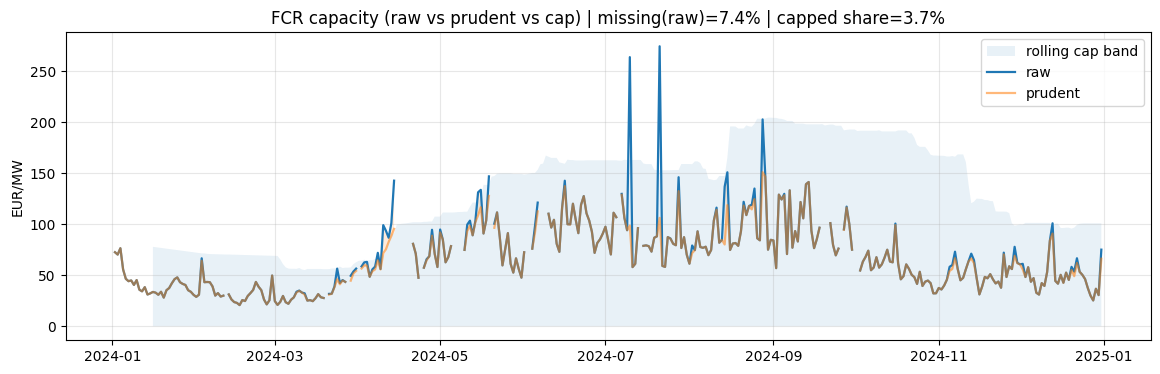

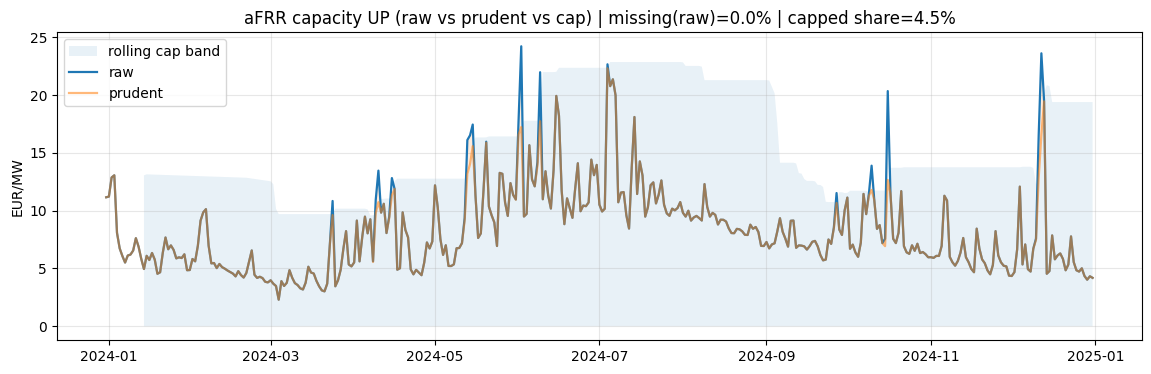

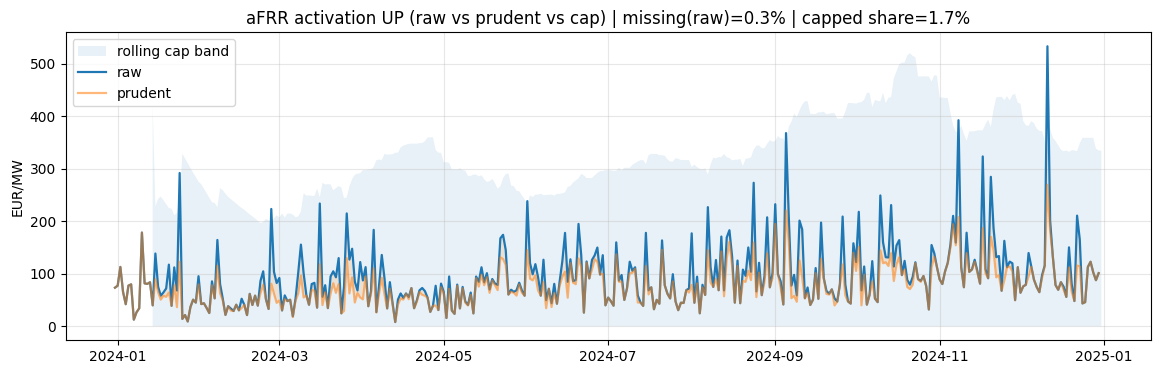

In [9]:
# 3 separate plots for FCR, afrr cap, afrr activation
plot_prudence_component(
    best_case_revenue,
    raw_col="FCR_capacity_EUR/MW",
    prudent_col="FCR_capacity_prudent",
    cap_col="cap_fcr",
    title="FCR capacity (raw vs prudent vs cap)",
    resample="D"
)

plot_prudence_component(
    best_case_revenue,
    raw_col="aFRR_capacity_UP_EUR/MW",
    prudent_col="aFRR_capacity_UP_prudent",
    cap_col="cap_afrr_cap_up",
    title="aFRR capacity UP (raw vs prudent vs cap)",
    resample="D"
)

plot_prudence_component(
    best_case_revenue,
    raw_col="aFRR_activation_UP_EUR/MW",
    prudent_col="aFRR_activation_UP_prudent",
    cap_col="cap_afrr_act_up",
    title="aFRR activation UP (raw vs prudent vs cap)",
    resample="D"
)



In [10]:
def capping_stats(raw, cap):
    m = raw.notna() & cap.notna()
    exceed = m & (raw > cap)
    return {
        "cap_defined_share": cap.notna().mean(),
        "exceed_count": int(exceed.sum()),
        "exceed_share_of_defined": float(exceed.sum() / max(m.sum(), 1)),
        "avg_exceedance": float((raw[exceed] - cap[exceed]).mean()) if exceed.any() else 0.0
    }

print("FCR:", capping_stats(best_case_revenue["FCR_capacity_EUR/MW"], cap_fcr))
print("aFRR cap:", capping_stats(best_case_revenue["aFRR_capacity_UP_EUR/MW"], cap_afrr_cap))
print("aFRR act:", capping_stats(best_case_revenue["aFRR_activation_UP_EUR/MW"], cap_afrr_act))


FCR: {'cap_defined_share': np.float64(0.9589072282299373), 'exceed_count': 524, 'exceed_share_of_defined': 0.06697341513292433, 'avg_exceedance': 44.004693129771}
aFRR cap: {'cap_defined_share': np.float64(0.9617529880478087), 'exceed_count': 435, 'exceed_share_of_defined': 0.05148538288554859, 'avg_exceedance': 3.06912}
aFRR act: {'cap_defined_share': np.float64(0.9617529880478087), 'exceed_count': 594, 'exceed_share_of_defined': 0.07057984790874525, 'avg_exceedance': 285.80077020202043}


In [11]:
# Example: simulate annual totals from prudent revenue per MW
s = best_case_revenue["total_revenue_prudent"].dropna()

sims = revenue_scenarios_stationary_bootstrap(s, n_sims=2000, exp_block_len=48)
annual_totals = sims.sum(axis=1)  # EUR/MW-year

p50 = np.quantile(annual_totals, 0.50)
p90 = np.quantile(annual_totals, 0.10)  # 90% exceedance => 10th percentile
print("Annual revenue EUR/MW: P50=", p50, " P90=", p90)


Annual revenue EUR/MW: P50= 1225081.96974125  P90= 1177077.2800404998


**Interpretation and Intuition:**

Stationary Bootstrap is used here to simulate future revenue scenarios while maintaining the temporal dependency (correlation) in the data. It generates multiple scenarios by reordering the original data, creating realistic future paths that are consistent with past data.

By analyzing the P50 and P90 percentiles, you can understand the expected total revenue (P50) and the potential downside risk (P90) over an annual period. For example:
- P50 could represent a base-case scenario (what's expected if the market behaves similarly to historical patterns).
- P90 could represent a stress test scenario, highlighting the risk of low revenue given the variability in the market.